In [47]:
import pathlib

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import copernicusmarine

datadir = pathlib.Path("data").absolute()
datadir.mkdir(exist_ok=True, parents=True)


In [4]:
def login(username, password):
    copernicusmarine.login(username=username, password=password)

In [7]:
def retrieve(variables=["uo", "vo","so", "thetao"]):
    copernicusmarine.subset(
        dataset_id="cmems_mod_glo_phy_anfc_0.083deg_PT1H-m",
        variables=variables,
        minimum_longitude=-7.960792,
        maximum_longitude=11.087939,
        minimum_latitude=-5.457782,
        maximum_latitude=9.952427,
        start_datetime="2026-08-06T00:00:00",
        end_datetime="2026-08-06T00:00:00",
        minimum_depth=0.49402499198913574,
        maximum_depth=0.49402499198913574,
        file_format="zarr",
        output_directory=datadir
    )

In [6]:
retrieve()

INFO - 2026-08-08T23:16:21Z - Selected dataset version: "202406"
INFO - 2026-08-08T23:16:21Z - Selected dataset part: "default"
INFO - 2026-08-08T23:16:27Z - Total size of the download: 510.05 KB.


In [9]:
ds = xr.open_dataset("data/cmems_mod_glo_phy_anfc_0.083deg_PT1H-m_uo-vo-so_7.92W-11.08E_5.42S-9.92N_0.49m_2026-08-06.zarr")

In [10]:
ds

<xarray.Dataset> Size: 510kB
Dimensions:    (time: 1, depth: 1, latitude: 185, longitude: 229)
Coordinates:
  * time       (time) datetime64[ns] 8B 2026-08-06
  * depth      (depth) float32 4B 0.494
  * latitude   (latitude) float32 740B -5.417 -5.333 -5.25 ... 9.75 9.833 9.917
  * longitude  (longitude) float32 916B -7.917 -7.833 -7.75 ... 10.92 11.0 11.08
Data variables:
    so         (time, depth, latitude, longitude) float32 169kB ...
    uo         (time, depth, latitude, longitude) float32 169kB ...
    vo         (time, depth, latitude, longitude) float32 169kB ...
Attributes:
    Conventions:               CF-1.8
    area:                      Global
    contact:                   https://marine.copernicus.eu/contact
    credit:                    E.U. Copernicus Marine Service Information (CM...
    institution:               Mercator Ocean International
    licence:                   http://marine.copernicus.eu/services-portfolio...
    producer:                  CMEMS - Global Monitoring and Forecasting Centre
    references:                http://marine.copernicus.eu
    source:                    MOI GLO12
    title:                     hourly mean fields from Global Ocean Physics A...
    copernicusmarine_version:  2.4.1

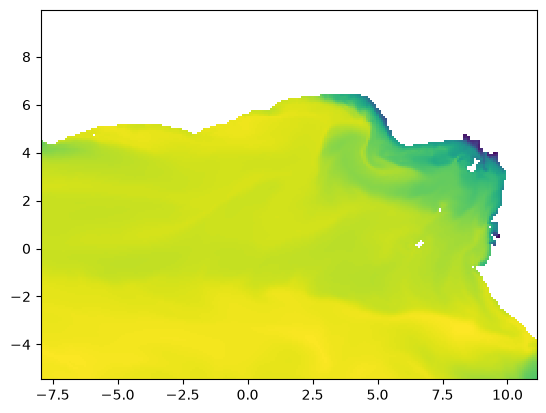

In [18]:
plt.pcolormesh(ds.longitude, ds.latitude, ds.so[0,0,:,:])

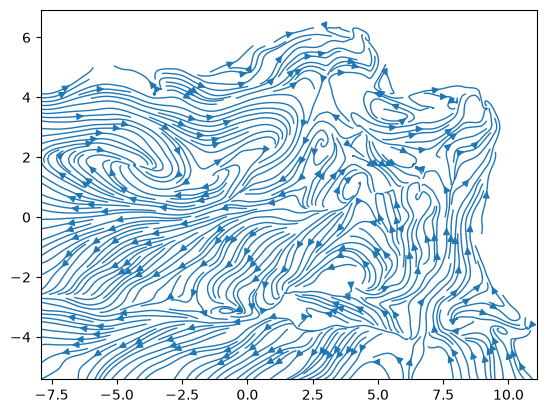

In [46]:
#lon = ds.longitude
lon = np.linspace(ds.longitude[0].item(), ds.longitude[-1].item(), len(ds.longitude))
lat = np.linspace(ds.latitude[0].item(), ds.latitude[-1].item(), len(ds.latitude))
lons,lats = np.meshgrid(lon,lat)

plt.streamplot(lons, lats, ds.uo[0,0,:,:].values, ds.vo[0,0,:,:].values, density=4, linewidth=1)

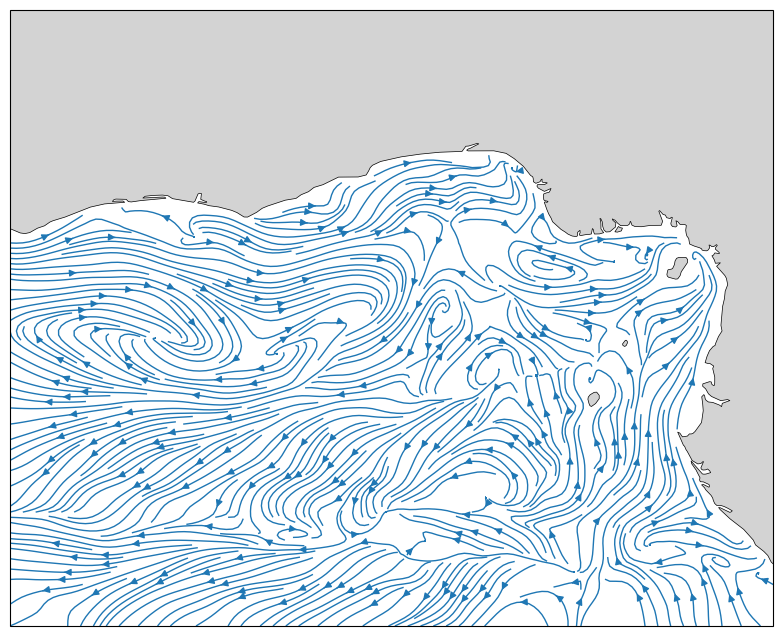

In [48]:
fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([lon.min(), lon.max(), lat.min(), lat.max()], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=2)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=3)

ax.streamplot(
    lons, lats, ds.uo[0, 0, :, :].values, ds.vo[0, 0, :, :].values,
    density=4, linewidth=1, transform=ccrs.PlateCarree()
)

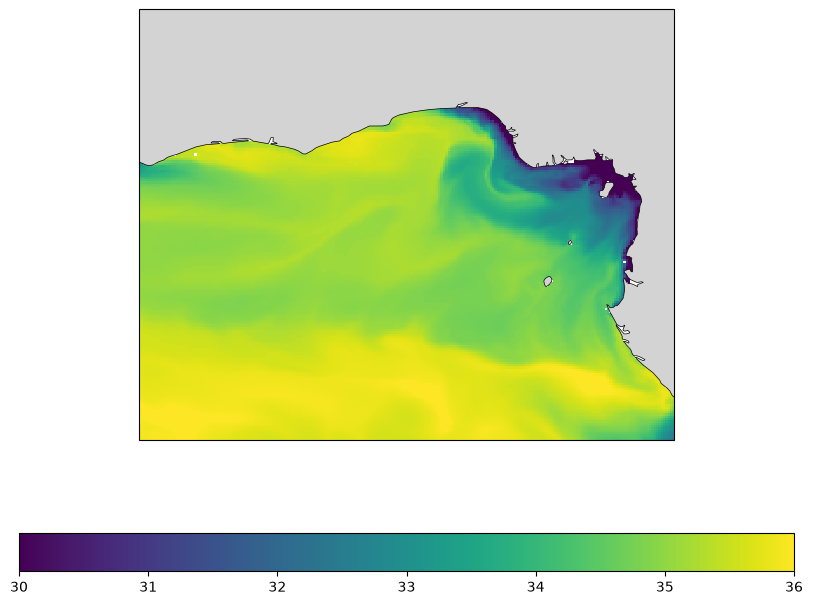

In [55]:
fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([lon.min(), lon.max(), lat.min(), lat.max()], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=2)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=3)

plt.pcolormesh(lons, lats, ds.so[0,0,:,:])
plt.clim(30,36)
plt.colorbar(orientation="horizontal")

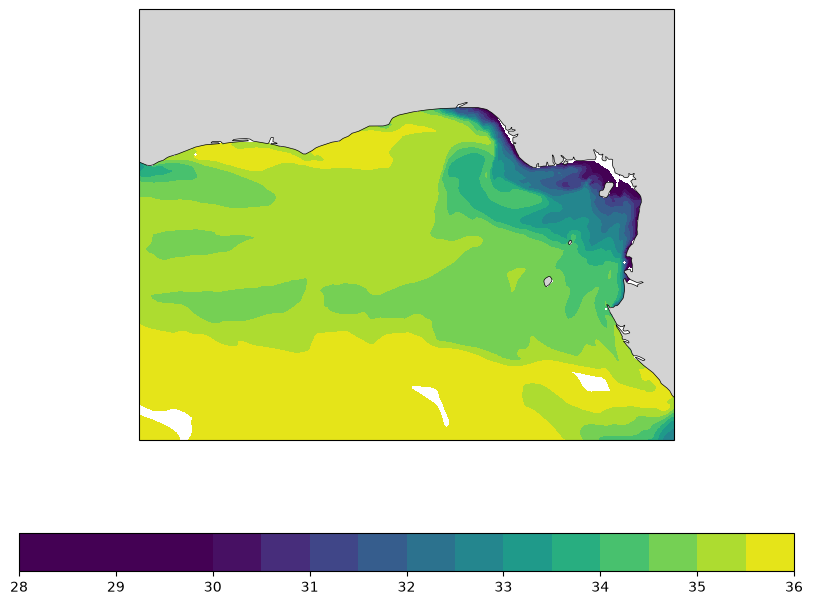

In [59]:
fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([lon.min(), lon.max(), lat.min(), lat.max()], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=2)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=3)

plt.contourf(lons, lats, ds.so[0,0,:,:], np.arange(28,36.5,0.5))
plt.clim(30,36)
plt.colorbar(orientation="horizontal")